PREPROCESSING & MODELING NOTEBOOK

### 0. Setup & Imports

#### Comments:

- By combining the red and white wine datasets, the analysis is increased to 6,497 total observations. This increased sample size provides a stronger foundation for training and tuning the models. This helps mitigate the potential issues of class imbalance mentioned my data memo

In [ ]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import FunctionTransformer

# dataset
file_path = "C:/Users/ryanf/Desktop/Final Project (pstat131)/Dataset/winequality-combined.csv"
df = pd.read_csv(file_path)

# verification for loading my dataset
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


### 1. Data Splitting and Stratification

For this combined wine dataset, I split it into training and testing sets using an 80/20 split. I used a stratified sampling approach (stratifying by the target variable, quality) to ensure that the class distribution in the training split ($N=5,197$) remains representative of the testing split ($N=1,300$).

#### Comments:

- The training set contains 5,197 observations and the testing set contains 1,300 observations
- The distribution check confirms that the imbalance in the target variable is kept across both datasets. This lets rarer quality scores like 3 (0.46%) and 9 (0.08%) are represented proportionately
- This stratification is needed for unbiased model evaluation. Since the dataset is heavily skewed toward mid range quality scores (5 and 6), standard random splitting could have accidentally excluded the extreme values (3s and 9s) from either the training or the testing set. So, using stratification makes sure the model is trained on the full range of data and evaluated on a test set that accurately mirrors the overall population. This helps prevent performance metrics from being artificially inflated or deflated by an unrepresentative sample.

In [20]:
# converting categorical 'type' column into a numeric dummy var
df_encoded = pd.get_dummies(df, columns=['type'], drop_first=True)

# feature matrix (X) and target vector (y)
X = df_encoded.drop('quality', axis=1)
y = df_encoded['quality']

# stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    stratify=y, 
    random_state=123
)

# verification for dimensions of new datasets
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape:  {X_test.shape}")

# verification for working stratification
print("\nTraining Set Quality Distribution (Proportions):")
print(y_train.value_counts(normalize=True).sort_index().round(4))

Training Features Shape: (5197, 12)
Testing Features Shape:  (1300, 12)

Training Set Quality Distribution (Proportions):
quality
3    0.0046
4    0.0333
5    0.3290
6    0.4366
7    0.1661
8    0.0296
9    0.0008
Name: proportion, dtype: float64


### 2. Preprocessing and Cross Validation Strategy

I made a ColumnTransformer pipeline that addresses the distributional irregularities I found during EDA.

#### Comments:

- Based on the histogram analysis, I found specific predictors (residual sugar, chlorides, free sulfur dioxide, sulphates) as heavily right skewed. Thus, I used a logarithmic transformation (np.log1p) to these variables to pull in extreme tails and approximate normality
- I used StandardScaler to all continuous features. This is a needed step for models like Elastic Net (which requires scaling for accurate shrinkage penalties) and K-Nearest Neighbors (which is sensitive to the scale of input features).
- I did a 10 fold Cross Validation strategy (KFold) with shuffling. This gives a strong framework to estimate model generalization performance and prevents overfitting during the the following hyperparameter tuning steps

In [21]:
# 10 fold cross validation on training data
cv_folds = KFold(n_splits=10, shuffle=True, random_state=123)

# isolates heavily skewed features I found during EDA
skewed_features = ['residual sugar', 'chlorides', 'free sulfur dioxide', 'sulphates']

# remaining features
standard_features = [col for col in X_train.columns if col not in skewed_features]

# np.log1p (log(1+x)) to handle transformations
log_transformer = FunctionTransformer(np.log1p, validate=True)

# preprocessor: log transform + scale the skewed ones, just scale the rest
preprocessor = ColumnTransformer(
    transformers=[
        ('log_and_scale', Pipeline([
            ('log', log_transformer),
            ('scaler', StandardScaler())
        ]), skewed_features),
        ('standard_scale', StandardScaler(), standard_features)
    ],
    remainder='passthrough' # this just makes sure any unlisted columns are not dropped
)

### 3. Model Pipeline Architecture

I wanted a reproducible and clean workflow so I put each mdel into Pipeline objects. This makes sure all the preprocessing are automatically applied to the training folds within each cross validation iteration. This eliminates my perpetual giant fear and the risk of infamous data leakage.

#### Comments:

- Elastic Net (elastic_net_pipe): A regularized linear regression model that combines Lasso and Ridge penalties. This makes it ideal for high dimensional data where variables may be correlated
- K-Nearest Neighbors (knn_pipe): A non parametric and distance based algorithm that provides a useful contrast to the linear baseline
- Random Forest (rf_pipe): An ensemble tree based method that gives a non linear baseline which can capture interactions without the assumptions of linear models.
- Gradient Boosting (gb_pipe): An ensemble method that builds an additive model in a forward stage wise fashion. It iteratively trains weak learners (typically shallow trees) to minimize the residual errors of the previous ensemble.This provides predictive flexibility and is effective for complex and non linear relationships in the data.

In [22]:
# pipeline 1: Elastic Net
elastic_net_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('enet', ElasticNet(random_state=123, max_iter=10000))
])

# pipeline 2: K-Nearest Neighbors
knn_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', KNeighborsRegressor())
])

# pipeline 3: Random Forest
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestRegressor(random_state=123))
])

# pipeline 4: Gradient Boosting
gb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('gb', GradientBoostingRegressor(random_state=123))
])

# verification for cv and pipelines
print("Cross Validation and Model Pipelines successfully created and complete")

Cross Validation and Model Pipelines successfully created and complete


### 4. Hyperparameter Tuning Grids

In order for me to find the optimal set up for each algorithm, I coded the following cell that establishes the hyperparameter grids and search objects using the 10 fold cross validation strategy defined previously. Each model is evaluated using Negative Mean Squared Error (MSE) to determine the best fit.


#### Comments:

- Elastic Net: Tuning alpha (the overall regularization strength) and the l1_ratio (the balance between the $L_{1}$ Lasso penalty and the $L_{2}$ Ridge penalty)
- K-Nearest Neighbors (KNN): Testing various neighborhood sizes (n_neighbors) ranging from 3 to 21, with different distance weighting functions (uniform vs. distance)
- Gradient Boosting: Tuning the ensemble by varying the number of boosting stages (n_estimators), the learning rate (which controls the contribution of each tree), and the maximum depth of individual trees. This method builds trees sequentially where each new tree attempts to minimize the residual errors of the previous ensemble. This provides an approach to capturing non linear relationships in the wine chemistry data
- Random Forest: Tuning the complexity of the ensemble to manage the bias variance tradeoff by varying the number of trees (n_estimators), the maximum depth of each tree (max_depth), and the subset of features considered at each split (max_features)
- GridSearchCV automates the search over these parameters which helps make sure the final models are optimized for predictive accuracy before any evaluation

In [23]:
# grids and searches
# elastic net
enet_grid = {'enet__alpha': [0.001, 0.01, 0.1, 1.0, 10.0], 'enet__l1_ratio': [0.0, 0.2, 0.5, 0.8, 1.0]}
enet_search = GridSearchCV(elastic_net_pipe, enet_grid, cv=cv_folds, scoring='neg_mean_squared_error', n_jobs=-1)

# k nearest neighbors
knn_grid = {'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 21], 'knn__weights': ['uniform', 'distance']}
knn_search = GridSearchCV(knn_pipe, knn_grid, cv=cv_folds, scoring='neg_mean_squared_error', n_jobs=-1)

# gradient boosting
gb_grid = {
    'gb__n_estimators': [100, 200, 300],
    'gb__learning_rate': [0.01, 0.1, 0.2],
    'gb__max_depth': [3, 5, 7]
}
gb_search = GridSearchCV(gb_pipe, gb_grid, cv=cv_folds, 
                         scoring='neg_mean_squared_error', n_jobs=-1)

# random forest
rf_grid = {'rf__n_estimators': [100, 200, 300], 'rf__max_features': ['sqrt', 'log2', 1.0], 'rf__max_depth': [None, 10, 20, 30]}
rf_search = GridSearchCV(rf_pipe, rf_grid, cv=cv_folds, scoring='neg_mean_squared_error', n_jobs=-1)

 # verification for grids and searches
print("Grid and Search objects successfuly defined.")

Grid and Search objects successfuly defined.


### 5. Elastic Net Results & Interpretation

#### Comments:

- The grid search successfully converged and found an optimal alpha of 0.01 and an l1_ratio of 0.2. This got a cross validated RMSE of 0.7281
- Since the optimal l1_ratio is 0.2, the Elastic Net model relies more heavily on the Ridge ($L_2$) penalty (80%) than the Lasso ($L_1$) penalty (20%). This supports my earlier EDA findings. Since several physicochemical properties (like total and free sulfur dioxide, or density and alcohol) are highly correlated, the Ridge penalty is doing the heavy lifting to manage the multicollinearity without dropping the correlated features entirely

In [24]:
# elastic net
print("Tuning Elastic Net in progress")
enet_search.fit(X_train, y_train)

# RMSE from the negative MSE score
enet_best_rmse = np.sqrt(-enet_search.best_score_)

print(f"Elastic Net Tuning Done:")
print(f"Best Parameters: {enet_search.best_params_}")
print(f"Best CV RMSE: {enet_best_rmse:.4f}")

Tuning Elastic Net in progress
Elastic Net Tuning Done:
Best Parameters: {'enet__alpha': 0.01, 'enet__l1_ratio': 0.2}
Best CV RMSE: 0.7281


### 6. K-Nearest Neighbors Results & Interpretation

#### Comments:

- The KNN model got a best cross validated RMSE of 0.6143 which currently outperforms the Elastic Net baseline. The optimal configuration found 21 neighbors with distance weighting. This means the model makes predictions by giving more influence to the chemical profiles of wines that are geographically closer in the feature space than to those further away
- This result suggests that the relationship between wine chemistry and quality is likely non linear since the non parametric KNN approach was able to capture local patterns that the globally constrained Elastic Net model missed

In [25]:
# k-nearest neighbors
print("Tuning K-Nearest Neighbors in progress")
knn_search.fit(X_train, y_train)

# RMSE from the negative MSE score
knn_best_rmse = np.sqrt(-knn_search.best_score_)

print(f"KNN Tuning Done:")
print(f"Best Parameters: {knn_search.best_params_}")
print(f"Best CV RMSE: {knn_best_rmse:.4f}")

Tuning K-Nearest Neighbors in progress
KNN Tuning Done:
Best Parameters: {'knn__n_neighbors': 21, 'knn__weights': 'distance'}
Best CV RMSE: 0.6143


### 7. Random Forest Results & Interpretation

#### Comments:

- The Random Forest model got a best cross validated RMSE of 0.6028. This makes currently the strongest performer among my three models tested. The optimal setup used 300 trees (n_estimators) with a deep structure (max_depth: 30) and sqrt for max_features which is the standard recommendation for regression tasks to ensure proper decorrelation between individual trees
- By reducing the error compared to the Elastic Net and edging out the K-Nearest Neighbors model, these results show that the relationship between the physicochemical properties and wine quality is complex and non linear
- The success of the Random Forest (specifically the sqrt feature splitting)suggests that interactions between these variables are better captured by an ensemble of decision trees than by a linear or distance based approach

In [26]:
# random forest
print("Tuning Random Forest in progress")
rf_search.fit(X_train, y_train)

# RMSE from the negative MSE score
rf_best_rmse = np.sqrt(-rf_search.best_score_)

print(f"Random Forest Tuning Done:")
print(f"Best Parameters: {rf_search.best_params_}")
print(f"Best CV RMSE: {rf_best_rmse:.4f}")

Tuning Random Forest in progress
Random Forest Tuning Done:
Best Parameters: {'rf__max_depth': 30, 'rf__max_features': 'sqrt', 'rf__n_estimators': 300}
Best CV RMSE: 0.6028


### 8. Gradient Boosting Results & Interpretation

#### Comments:

- The Gradient Boosting model got a best cross validated RMSE of 0.6182. The optimal setup selected 300 boosting stages (n_estimators), a learning rate of 0.1, and a tree structure (max_depth: 7) to sequentially minimize residual errors
-  While this model outperforms the linear Elastic Net baseline (0.7281), it underperforms relative to the K-Nearest Neighbors model (0.6143) and the Random Forest model (0.6028) in cross validation 
- The selection of a relatively high maximum depth (7) suggests that the boosting algorithm needed to construct complex and multi variable rules to capture the non linear chemistry interactions. This supports my earlier EDA findings that global linear assumptions are insufficient for this dataset

In [27]:
# gradient boosting
print("Tuning Gradient Boosting in progress")
gb_search.fit(X_train, y_train)

# RMSE from the negative MSE score
gb_best_rmse = np.sqrt(-gb_search.best_score_)

print(f"Gradient Boosting Tuning Done:")
print(f"Best Parameters: {gb_search.best_params_}")
print(f"Best CV RMSE: {gb_best_rmse:.4f}")

Tuning Gradient Boosting in progress
Gradient Boosting Tuning Done:
Best Parameters: {'gb__learning_rate': 0.1, 'gb__max_depth': 7, 'gb__n_estimators': 300}
Best CV RMSE: 0.6182


### 9. Test Set Evaluation

Ideally, in a setting outside of this upper division elective course, liek a personal/side project, I would attempt to evaluate each tuned model on the held out test dataset (N = 1,300) using RMSE and R². However, per the project rubric requirements, only the top "one or two" performing models from the cross validation phase are evaluated on the held out test dataset (N=1,300). Thus, based on the CV RMSE scores, Random Forest (0.6028) and K Nearest Neighbors (0.6143) were selected as the top two models to move forward. 

#### Comments:

- Random Forest is the strongest performer with a test RMSE of 0.6048 and an R² of 0.5209. This model explains about 52% of the variance in wine quality scores
- KNN is competitive (RMSE 0.6168, R² 0.5017)
- Both CV RMSE values translate to the test set with no meaningful jumps. This confirms the pipeline successfully prevented data leakage and that both models generalize well to unseen data

In [28]:
# predictions from top 2 best estimators only (Random Forest & KNN) (project requirements)
knn_pred = knn_search.best_estimator_.predict(X_test)
rf_pred = rf_search.best_estimator_.predict(X_test)

# RMSE and R^2 for each
knn_test_rmse = np.sqrt(mean_squared_error(y_test, knn_pred))
knn_test_r2 = r2_score(y_test, knn_pred)

rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_test_r2 = r2_score(y_test, rf_pred)

# results
print("Test Set Performance (Top 2 Models Only)")
print(f"{'Model':<20} {'Test RMSE':>12} {'Test R²':>10}")
print("-" * 44)
print(f"{'KNN':<20} {knn_test_rmse:>12.4f} {knn_test_r2:>10.4f}")
print(f"{'Random Forest':<20} {rf_test_rmse:>12.4f} {rf_test_r2:>10.4f}")

Test Set Performance (Top 2 Models Only)
Model                   Test RMSE    Test R²
--------------------------------------------
KNN                        0.6168     0.5017
Random Forest              0.6048     0.5209


### 10. Model Comparison Summary

This table summarizes the tuned hyperparameters and final performance metrics for all four models across cross validation. **Only the top two models** were evaluated on the held out test dataset.

| Model | Best Parameters | CV RMSE | Test RMSE | Test R² |
| :--- | :--- | :--- | :--- | :--- |
| Elastic Net | alpha: 0.01, l1_ratio: 0.2 | 0.7281 | N/A | N/A |
| KNN | n_neighbors: 21, weights: distance | 0.6143 | 0.6168 | 0.5017 |
| Gradient Boosting | learning_rate: 0.1, max_depth: 7, n_estimators: 300 | 0.6182 | N/A | N/A |
| Random Forest | max_depth: 30, max_features: sqrt, n_estimators: 300 | 0.6028 | 0.6048 | 0.5209 |

#### Comments:

- Random Forest is the best performing model across every metric
- Both K Nearest Neighbors and Random Forest show very little difference between their CV RMSE and Test RMSE. This confirms stable generalization and no overfitting
- Elastic Net and Gradient Boosting **were excluded** from the final test set evaluation as they were outperformed during cross validation. The general success of the non linear models (KNN, Random Forest, and Gradient Boosting) over the linear Elastic Net confirms that a simple linear decision boundary is insufficient for this dataset

In [29]:
# model comparison table
results = {
    'Model': ['Elastic Net', 'KNN', 'Gradient Boosting', 'Random Forest'],
    'Best Parameters': [
        str(enet_search.best_params_),
        str(knn_search.best_params_),
        str(gb_search.best_params_),
        str(rf_search.best_params_)
    ],
    'CV RMSE': [
        round(enet_best_rmse, 4),
        round(knn_best_rmse, 4),
        round(gb_best_rmse, 4),
        round(rf_best_rmse, 4)
    ],
    'Test RMSE': [
        'N/A', 
        round(knn_test_rmse, 4),
        'N/A', 
        round(rf_test_rmse, 4)
    ],
    'Test R²': [
        'N/A', 
        round(knn_test_r2, 4),
        'N/A', 
        round(rf_test_r2, 4)
    ]
}

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())

                                                                              Best Parameters  CV RMSE Test RMSE Test R²
Model                                                                                                                   
Elastic Net                                      {'enet__alpha': 0.01, 'enet__l1_ratio': 0.2}   0.7281       N/A     N/A
KNN                                      {'knn__n_neighbors': 21, 'knn__weights': 'distance'}   0.6143    0.6168  0.5017
Gradient Boosting     {'gb__learning_rate': 0.1, 'gb__max_depth': 7, 'gb__n_estimators': 300}   0.6182       N/A     N/A
Random Forest      {'rf__max_depth': 30, 'rf__max_features': 'sqrt', 'rf__n_estimators': 300}   0.6028    0.6048  0.5209


### 11. Random Forest Feature Importances

I created this bar chart that ranks all 12 features by their Mean Decrease in Impurity. This measures how much each variable contributes to reducing prediction error across all 300 trees in the ensemble.

#### Comments:

- Alcohol is the most important feature (0.174), nearly 60% more influential than the next closest predictor. This confirms my EDA finding where higher alcohol content was visually associated with higher quality scores across both wine types
- Volatile acidity (0.111) and density (0.110) are nearly tied for second. Volatile acidity's ranking aligns directly with the EDA boxplots showing its negative relationship with quality. Density's high importance is interesting since it has moderate correlation with quality (-0.31) in the heatmap. This possibly suggests it captures non linear interactions the correlation matrix alone couldn't show
- The sulfur dioxide variables, chlorides, sulphates, and residual sugar form a middle tier of moderate importance (0.075 to 0.087). Each contributes meaningfully but no single one dominates
- type_white (0.005) is negligible which suggests that once the physicochemical properties are accounted for, whether a wine is red or white adds almost no additional predictive power

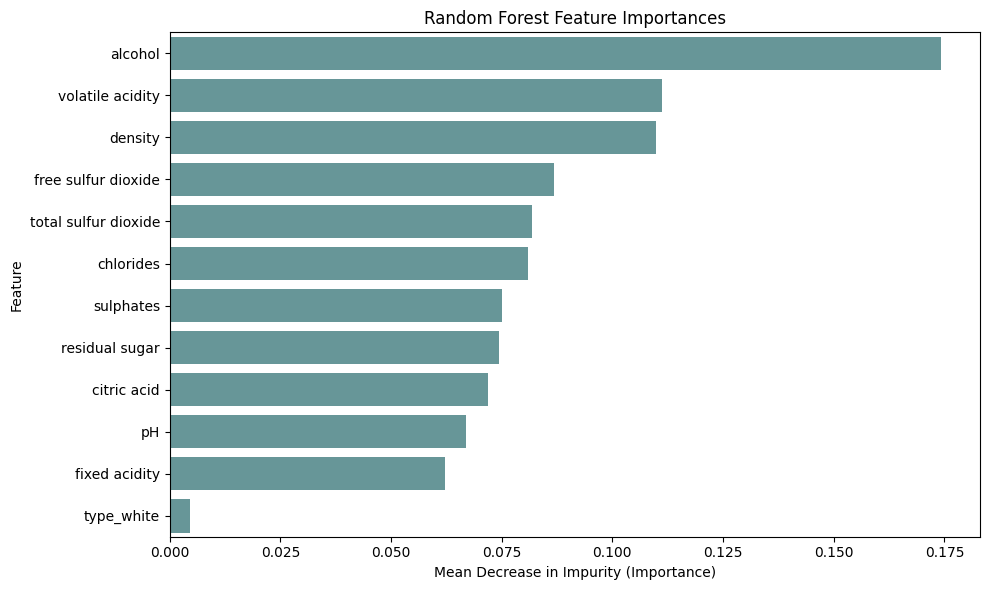

             Feature  Importance
             alcohol    0.174329
    volatile acidity    0.111207
             density    0.109879
 free sulfur dioxide    0.086820
total sulfur dioxide    0.081788
           chlorides    0.080964
           sulphates    0.075122
      residual sugar    0.074363
         citric acid    0.071808
                  pH    0.067050
       fixed acidity    0.062125
          type_white    0.004545


In [30]:
# feature important for random forest model

# gets feature names post preprocessing
# skewed features are log transformed + scaled, standard features are just scaled
feature_names = skewed_features + standard_features

# pulls feature importances from the best RF estimator
rf_best = rf_search.best_estimator_
importances = rf_best.named_steps['rf'].feature_importances_

# sorting by importance descending
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

# plot
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', color='#5f9ea0')
plt.title('Random Forest Feature Importances')
plt.xlabel('Mean Decrease in Impurity (Importance)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))

### 12. Predicted vs. Actual Wine Quality (Random Forest Model)

The scatter plot compares the Random Forest's predicted quality scores against the true quality scores on the held out test dataset. Points along the dashed red line represent perfect predictions.

#### Comments:

- The model performs best in the 5 and 6 range where the dense vertical clusters sit close to the perfect prediction line. This is expected given that the vast majority of training observations belong to these two scores
- The model shows a consistent regression toward the mean pattern at the extremes. For actual scores of 3 and 4, predictions are pulled upward toward 5. For actual scores of 8 and 9, predictions are pulled downward toward 6-7. This directly reflects the class imbalance I noted in the EDA where the model simply has far fewer examples of extreme wines to learn from
- The lone actual score of 9 in the test set is predicted around 7 which is the most visible single point miss in the plot. Again, this is a consequence of having only a handful of quality 9 wines in the entire dataset (0.08% of training observations)
- Overall the upward trend of the point clusters confirms the model has learned a meaningful signal. It is not a perfect predictor but given the inherent subjectivity of human expert wine scoring and the R² of 0.521, these results are reasonable and expected in my opinion

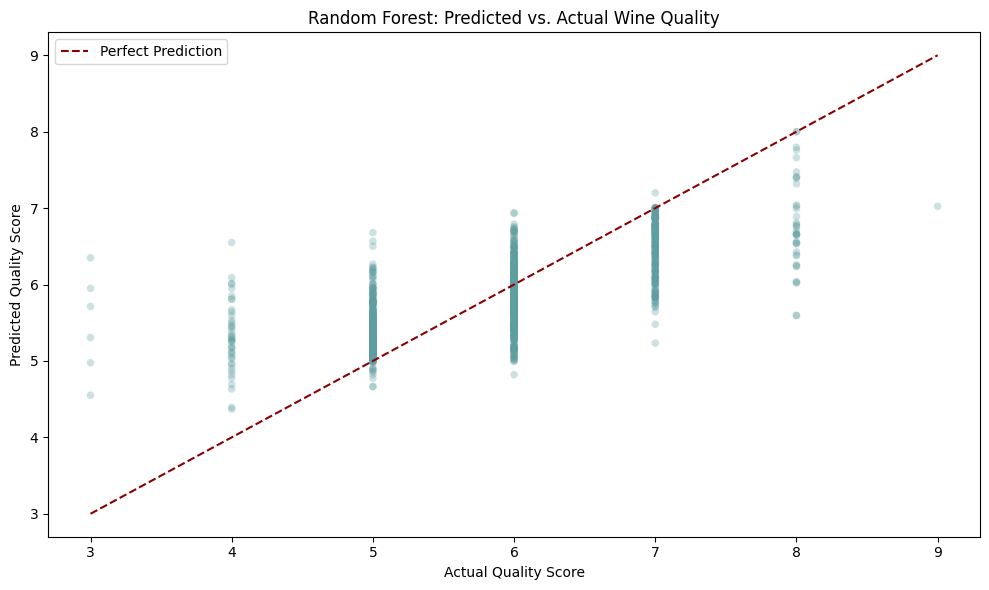

In [31]:
# predicted vs actual for random forest

plt.figure(figsize=(10, 6))
plt.scatter(y_test, rf_pred, alpha=0.3, color='#5f9ea0', edgecolors='none', s=30)

# perfect prediction reference line
min_val = min(y_test.min(), rf_pred.min())
max_val = max(y_test.max(), rf_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='#8b0000', linewidth=1.5,
         linestyle='--', label='Perfect Prediction')

plt.title('Random Forest: Predicted vs. Actual Wine Quality')
plt.xlabel('Actual Quality Score')
plt.ylabel('Predicted Quality Score')
plt.legend()
plt.tight_layout()
plt.show()

### 13. Residual Diagnostics (Random Forest)

#### Comments:

-  The distinct, parallel, downward sloping lines of points are a direct result of using a continuous regression model to predict discrete integer targets
- The plot visually confirms the model's boundary limitations I stated previously in this notebook and my prior EDA notebook. It systematically overpredicts poor quality wines (producing negative residuals on the left) and underpredicts high-quality wines (producing positive residuals on the right) 
- The densest cluster of points hugs the zero error reference line tightly between predicted values of 5.0 and 6.5. This confirms the model is highly reliable for average wines but struggles to capture the full variance of the rarer and more extreme outliers

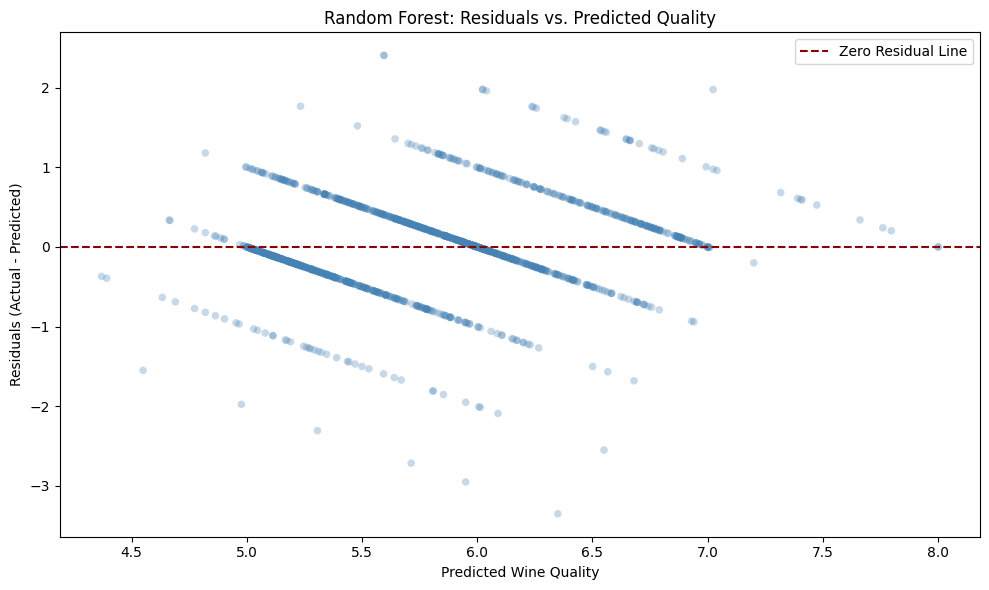

In [32]:
# calculate residuals
residuals = y_test - rf_pred

plt.figure(figsize=(10, 6))
plt.scatter(rf_pred, residuals, alpha=0.3, color='#4682b4', edgecolors='none', s=30)
plt.axhline(y=0, color='#8b0000', linewidth=1.5, linestyle='--', label='Zero Residual Line')

plt.title('Random Forest: Residuals vs. Predicted Quality')
plt.xlabel('Predicted Wine Quality')
plt.ylabel('Residuals (Actual - Predicted)')
plt.legend()
plt.tight_layout()
plt.show()